# Counting Molecules — Stage 3: Blob Detection and Counting

This notebook turns the binary masks from `02_binarization.ipynb` into actual molecule counts. It uses two complementary approaches:

1. **Connected-component labelling** (the workhorse): every connected region of True pixels in the binary mask becomes a labelled molecule, with a bounding box, area, perimeter, and other shape properties.
2. **Blob-detection algorithms** (LoG, DoG, DoH): three classical computer vision methods compared on the same image, to validate the labelling result and demonstrate when each method is appropriate.

**Author:** Stephanie Wainaina  
**Project type:** Monash data science studio  
**Stack:** Python, scikit-image, NumPy, Pandas, Matplotlib

> See the repo README for full project context. Data files are not included in this repository (proprietary research data), so cell outputs are saved for reference.

## 1. Setup

Self-contained: reloads the four STM images, re-applies mean-field correction and Otsu binarisation, then proceeds to blob detection. If you've already run Notebooks 01 and 02 in the same kernel session, the intermediate variables would also be available.

In [5]:
import os
import pickle
from math import sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Workaround: nanonispy v1.1.0 uses np.float which was removed in NumPy 1.20+
if not hasattr(np, "float"):
    np.float = float

np.int = int

import nanonispy as nap
from skimage.filters import threshold_otsu
from skimage.morphology import closing, square
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops, regionprops_table
from skimage.color import label2rgb
from skimage.feature import blob_log, blob_dog, blob_doh

DATA_DIR = r'C:\Users\steph\OneDrive\Desktop\github_rebuild\counting_molecules\Counting-Molecules\data'

## 2. Reload and prepare the four binary masks

The same loaders, mean-field correction, and binarisation pipeline from Stages 1 and 2, applied here so this notebook can be run independently.

In [3]:
def load_txt_image(filepath):
    return np.loadtxt(filepath)


def load_pickle_image(filepath):
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    return data["image"], data.get("rescale", None)


def load_sxm_image(filepath):
    scan = nap.read.Scan(filepath)
    image = scan.signals["Z"]["forward"]
    if scan.header["scan_dir"] == "down":
        image = np.flipud(image)
    image[np.isnan(image)] = np.mean(image[~np.isnan(image)])
    rescale = scan.header["scan_range"] / scan.header["scan_pixels"]
    return image, rescale


def remove_mean_field(image):
    corrected = image.copy().astype(float)
    corrected = corrected - np.mean(corrected, axis=0)[np.newaxis, :]
    corrected = corrected - np.mean(corrected, axis=1)[:, np.newaxis]
    return corrected


def binarise_stm_image(image, closing_size=3):
    threshold = threshold_otsu(image)
    binary = image > threshold
    binary = closing(binary, square(closing_size))
    binary = clear_border(binary)
    return binary

In [6]:
# Load, correct, and binarise all four images
image_a = load_txt_image(os.path.join(DATA_DIR, "1705_6.txt"))
image_b, _ = load_pickle_image(os.path.join(DATA_DIR, "111_test_data.p"))
image_c, _ = load_sxm_image(os.path.join(DATA_DIR, "Ag111_APT_007.sxm"))
image_d, _ = load_sxm_image(os.path.join(DATA_DIR, "180509_18-16-48_SPM001.sxm"))

corrected_images = {
    "Image A (.txt)": remove_mean_field(image_a),
    "Image B (.p)": remove_mean_field(image_b),
    "Image C (.sxm)": remove_mean_field(image_c),
    "Image D (.sxm)": remove_mean_field(image_d),
}

binarised_images = {
    name: binarise_stm_image(img) for name, img in corrected_images.items()
}

print("Ready for blob detection:")
for name, mask in binarised_images.items():
    print(f"  {name}: {mask.shape}, {mask.sum():,} molecule pixels")

Ready for blob detection:
  Image A (.txt): (556, 512), 340 molecule pixels
  Image B (.p): (512, 512), 15,354 molecule pixels
  Image C (.sxm): (1024, 1024), 116,897 molecule pixels
  Image D (.sxm): (768, 768), 110,858 molecule pixels


## 3. Connected-component labelling

The simplest counting strategy: every connected region of True pixels in the binary mask is a molecule. `skimage.measure.label` assigns each region a unique integer ID, and `regionprops` extracts shape and position properties from each labelled region.

Why this works for our data:
- Otsu thresholding has already separated molecules from background.
- Morphological closing has filled small gaps inside molecules.
- Border clearing has removed partial molecules at image edges.

So by the time we reach this stage, "True pixels touching each other" is a reliable proxy for "the same molecule."

A small area filter rejects connected regions of fewer than 50 pixels, which are almost always thresholding noise rather than real molecules.

In [7]:
def count_and_label_molecules(binary_mask, min_area=50):
    """Label connected regions in a binary mask and return molecule properties.

    Parameters
    ----------
    binary_mask : np.ndarray (bool)
        Binary mask where True indicates a molecule.
    min_area : int, optional
        Minimum region area in pixels to be counted as a molecule.
        Smaller regions are treated as thresholding noise. Default 50.

    Returns
    -------
    tuple of (np.ndarray, list, pd.DataFrame)
        - label_image: integer-labelled regions (0 = background)
        - regions: list of RegionProperties objects passing the min_area filter
        - props_df: DataFrame of area, perimeter, centroid, and bounding box for each molecule
    """
    label_image = label(binary_mask, background=0)
    all_regions = regionprops(label_image)
    regions = [r for r in all_regions if r.area >= min_area]

    props_df = pd.DataFrame([
        {
            "label": r.label,
            "area": r.area,
            "perimeter": r.perimeter,
            "centroid_y": r.centroid[0],
            "centroid_x": r.centroid[1],
            "bbox_min_row": r.bbox[0],
            "bbox_min_col": r.bbox[1],
            "bbox_max_row": r.bbox[2],
            "bbox_max_col": r.bbox[3],
        }
        for r in regions
    ])

    return label_image, regions, props_df

## 4. Apply labelling to all four images

For each image, we get a labelled region map, a list of region properties, and a tidy DataFrame ready for analysis.

In [8]:
results = {}

for name, mask in binarised_images.items():
    label_image, regions, props_df = count_and_label_molecules(mask, min_area=50)
    results[name] = {
        "label_image": label_image,
        "regions": regions,
        "props_df": props_df,
    }

# Summary count per image
print("Molecules detected per image (area >= 50 pixels):")
for name, r in results.items():
    print(f"  {name}: {len(r['regions']):,} molecules")

Molecules detected per image (area >= 50 pixels):
  Image A (.txt): 2 molecules
  Image B (.p): 86 molecules
  Image C (.sxm): 331 molecules
  Image D (.sxm): 97 molecules


## 5. Visualise: bounding boxes around every detected molecule

For each image, overlay coloured region labels on the mean-corrected scan, and draw a red bounding box around each molecule that passed the area filter.

c:\Users\steph\anaconda3\Lib\site-packages\skimage\color\colorlabel.py:149: UserWarning: Negative intensities in `image` are not supported
  rgb = _label2rgb_overlay(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


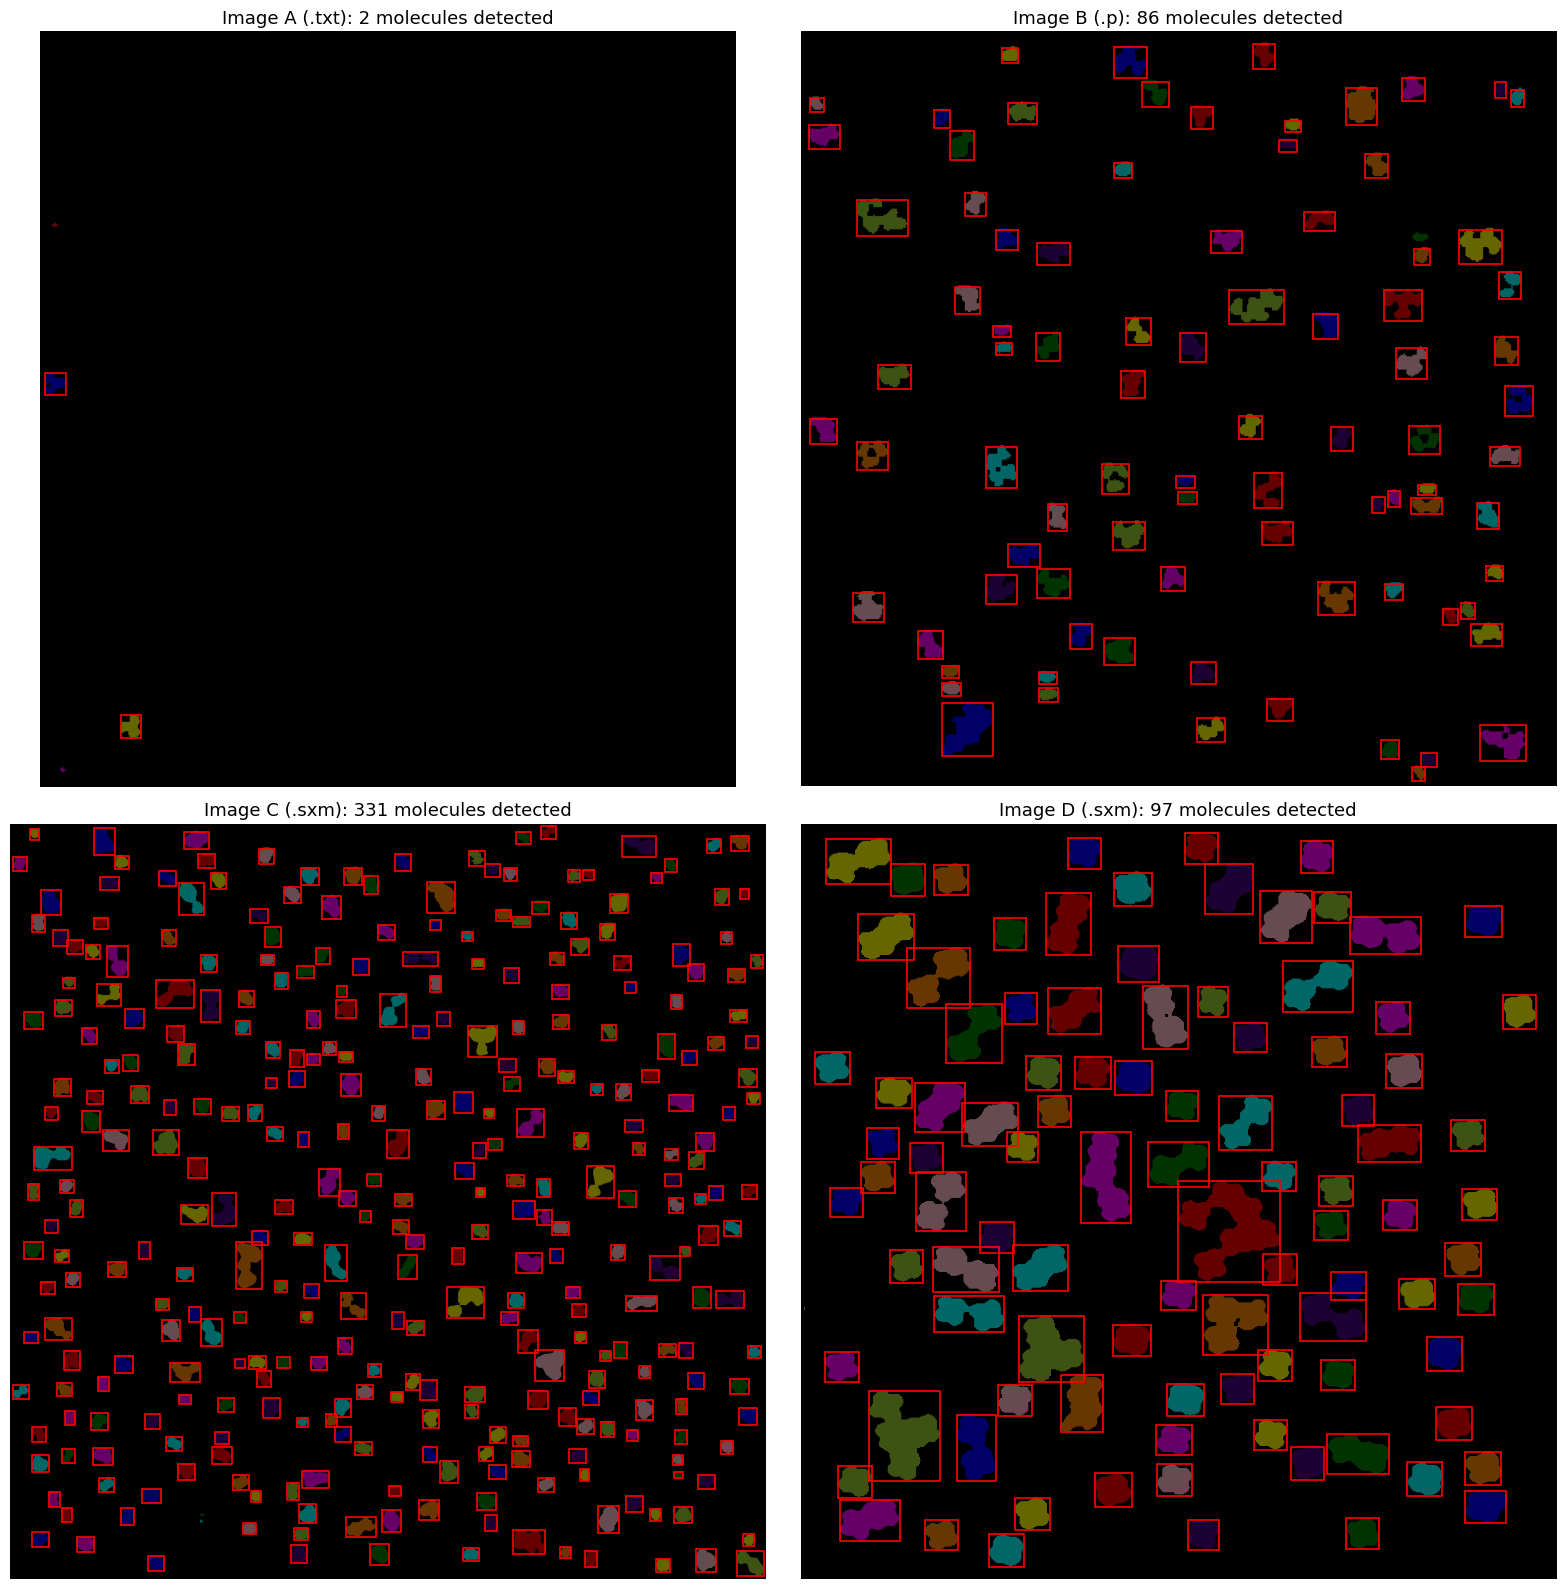

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

for ax, (name, r) in zip(axes.flat, results.items()):
    corrected = corrected_images[name]
    label_image = r["label_image"]
    regions = r["regions"]

    overlay = label2rgb(label_image, image=corrected, bg_label=0, alpha=0.4)
    ax.imshow(overlay)
    ax.set_title(f"{name}: {len(regions):,} molecules detected", fontsize=13)

    # Draw bounding box around each molecule that passed the area filter
    for region in regions:
        min_row, min_col, max_row, max_col = region.bbox
        rect = mpatches.Rectangle(
            (min_col, min_row),
            max_col - min_col,
            max_row - min_row,
            fill=False,
            edgecolor="red",
            linewidth=1.2,
        )
        ax.add_patch(rect)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

## 6. Shape features: area vs perimeter

If molecules of the same species are visually similar in shape and size, they should cluster together in feature space. A scatter plot of area against perimeter for every detected molecule is the simplest version of that test.

Distinct clusters in this plot suggest distinct molecular species; a single tight cloud suggests one dominant species; scattered noise without structure suggests our detection is picking up artefacts as well as molecules.

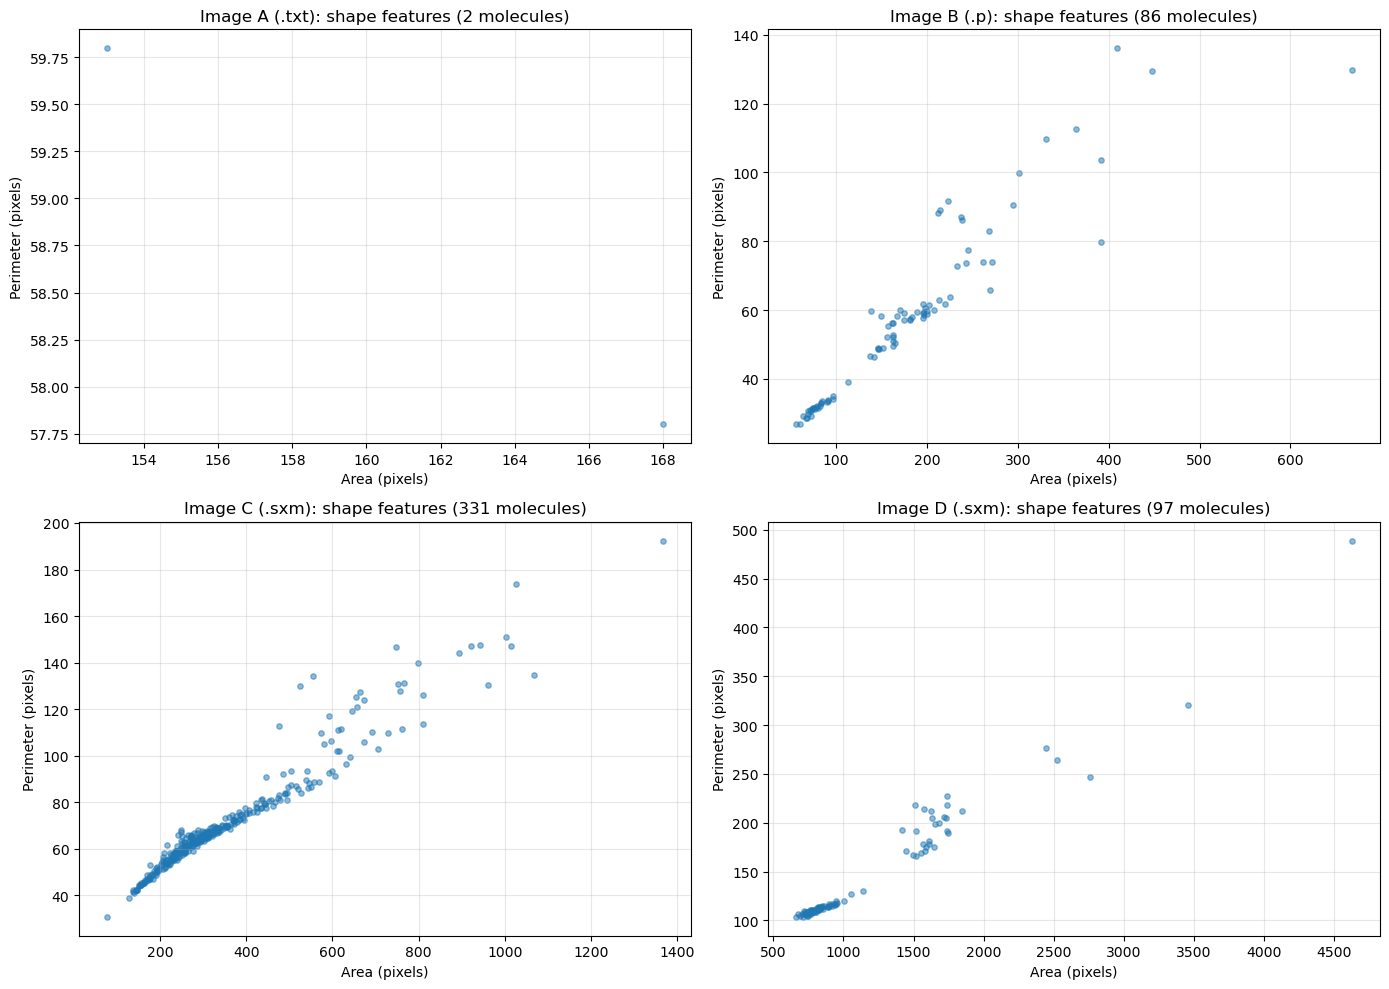

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, r) in zip(axes.flat, results.items()):
    df = r["props_df"]
    if len(df) > 0:
        ax.scatter(df["area"], df["perimeter"], alpha=0.5, s=15)
    ax.set_xlabel("Area (pixels)")
    ax.set_ylabel("Perimeter (pixels)")
    ax.set_title(f"{name}: shape features ({len(df):,} molecules)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. A glance at individual molecules

To verify the detection isn't picking up noise, here's a grid of the first 25 detected molecules from one image, cropped to their bounding boxes.

Showing first 25 molecules from: Image C (.sxm)


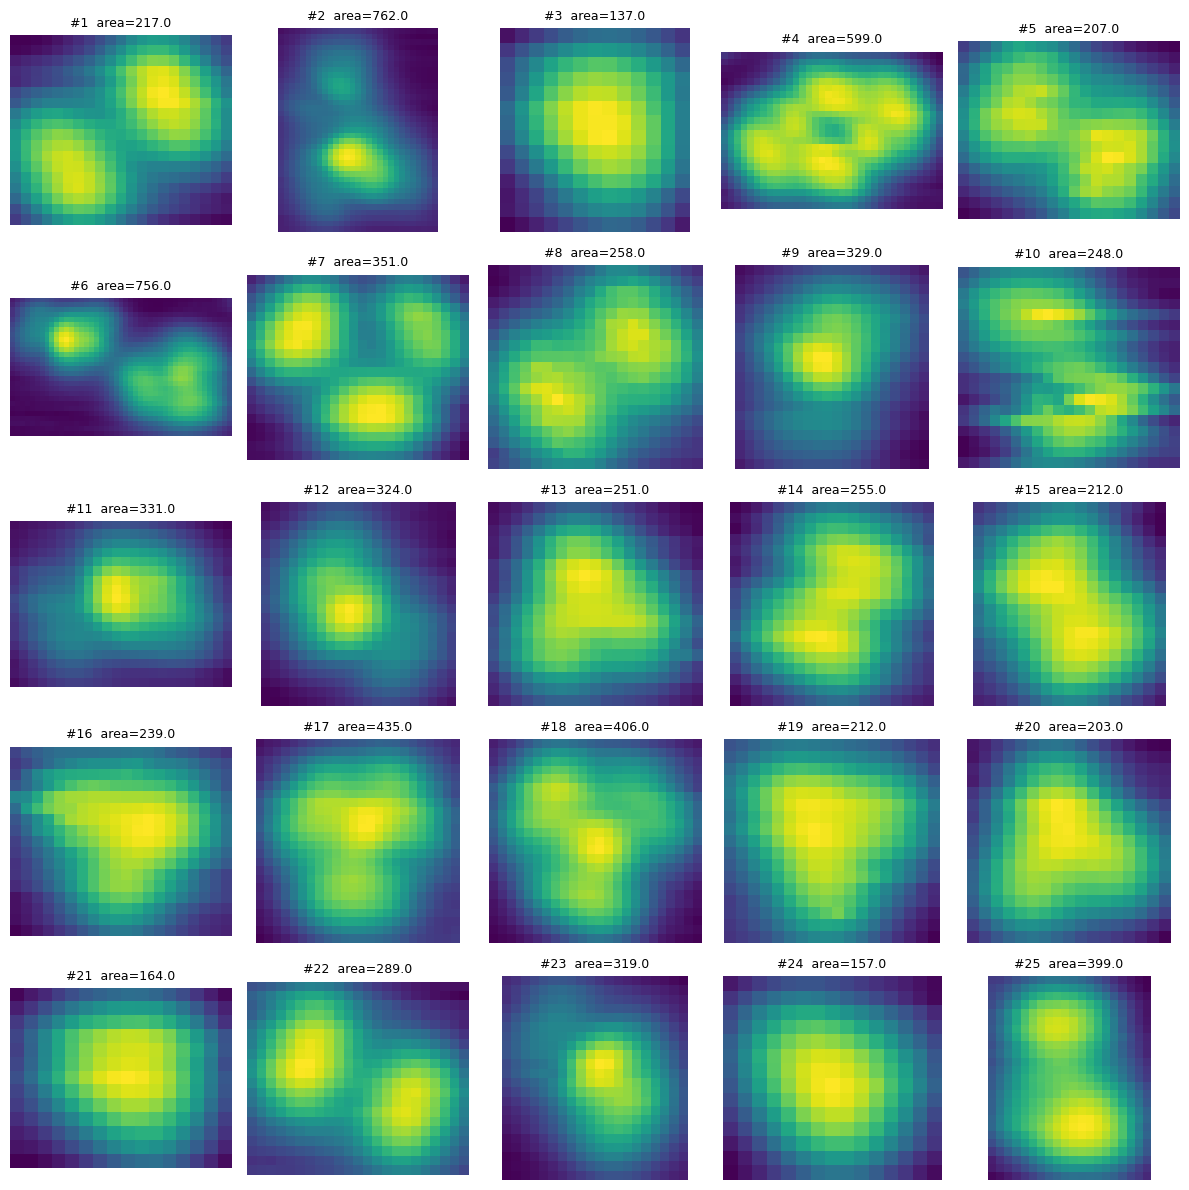

In [16]:
# Pick the image with the most detections for the gallery
sample_name = max(results.keys(), key=lambda n: len(results[n]["regions"]))
sample = results[sample_name]
sample_corrected = corrected_images[sample_name]

print(f"Showing first 25 molecules from: {sample_name}")

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
for i, region in enumerate(sample["regions"][:25]):
    ax = axes[i // 5, i % 5]
    min_row, min_col, max_row, max_col = region.bbox
    ax.imshow(sample_corrected[min_row:max_row, min_col:max_col], cmap="viridis")
    ax.set_title(f"#{region.label}  area={region.area}", fontsize=9)
    ax.axis("off")

# Hide any unused axes if there are fewer than 25 molecules
for i in range(len(sample["regions"][:25]), 25):
    axes[i // 5, i % 5].axis("off")

plt.tight_layout()
plt.show()

## 7.5. Single-image walkthrough: LoG vs DoG vs DoH

Before applying all three methods to every image, here's the classic 1x3 comparison on a single image. This is the visualisation pattern you'll see in most scikit-image blob detection tutorials, and it's the cleanest way to read each method's behaviour before the multi-image grid below.

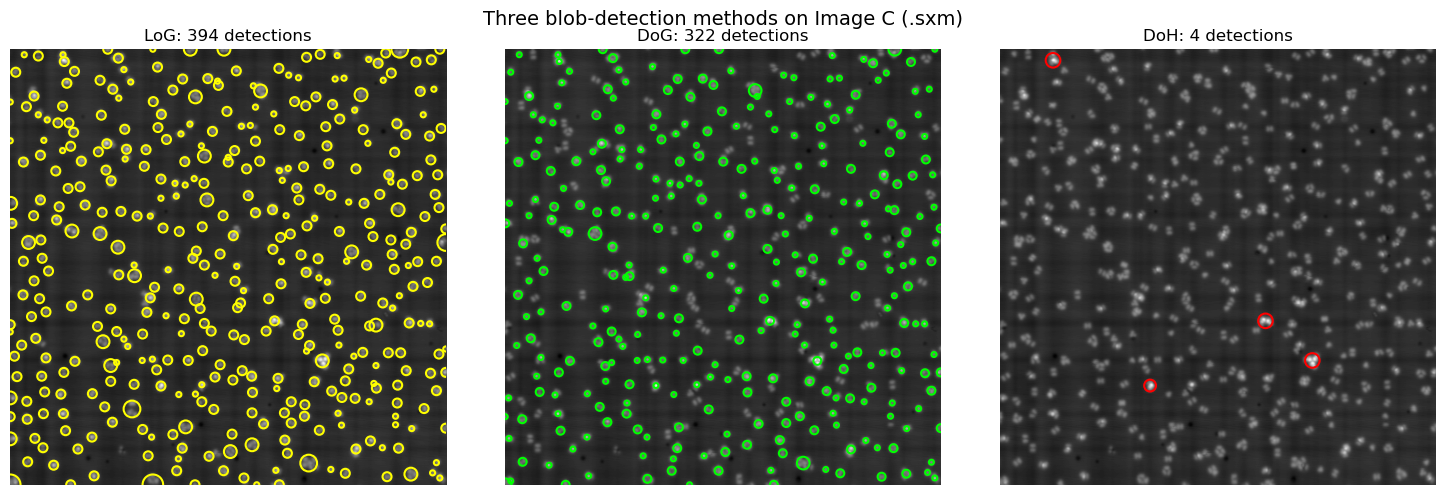

In [17]:
# Pick one image for the walkthrough (Image C has good mid-range complexity)
walkthrough_name = "Image C (.sxm)"
walkthrough_image = corrected_images[walkthrough_name]

blob_results = detect_blobs_three_ways(walkthrough_image)
colors_single = {"LoG": "yellow", "DoG": "lime", "DoH": "red"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, (method, blobs) in zip(axes, blob_results.items()):
    ax.imshow(walkthrough_image, cmap="gray")
    ax.set_title(f"{method}: {len(blobs):,} detections", fontsize=12)
    
    for y, x, radius in blobs:
        circle = plt.Circle((x, y), radius, color=colors_single[method], linewidth=1.5, fill=False)
        ax.add_patch(circle)
    
    ax.set_axis_off()

fig.suptitle(f"Three blob-detection methods on {walkthrough_name}", fontsize=14)
plt.tight_layout()
plt.show()

---

## Section 2: Blob detection algorithms (LoG, DoG, DoH)

Connected-component labelling worked because our binarisation was clean. But for noisier images, or for cases where molecules overlap, dedicated blob-detection algorithms can be more robust. scikit-image provides three classical methods:

- **Laplacian of Gaussian (LoG):** the most accurate, but the slowest. It convolves the image with a Laplacian-of-Gaussian filter at several scales and finds local maxima.
- **Difference of Gaussian (DoG):** a fast approximation of LoG. Subtracts a more-blurred copy of the image from a less-blurred one.
- **Determinant of Hessian (DoH):** the fastest, especially for large blobs. Uses the determinant of the image's Hessian matrix.

We compare all three on each image to see which finds the molecules most cleanly.

In [12]:
def detect_blobs_three_ways(image, max_sigma=30, threshold=0.1):
    """Run LoG, DoG, and DoH blob detection on the same image.

    Returns
    -------
    dict
        Keys: 'LoG', 'DoG', 'DoH'. Values: array of (y, x, radius) for each detected blob.
    """
    # Normalise to [0, 1] so threshold is comparable across images
    img_norm = (image - image.min()) / (image.max() - image.min())

    blobs_log = blob_log(img_norm, max_sigma=max_sigma, num_sigma=10, threshold=threshold)
    # blob_log returns sigma in the third column; convert to radius
    blobs_log[:, 2] = blobs_log[:, 2] * sqrt(2)

    blobs_dog = blob_dog(img_norm, max_sigma=max_sigma, threshold=threshold)
    blobs_dog[:, 2] = blobs_dog[:, 2] * sqrt(2)

    blobs_doh = blob_doh(img_norm, max_sigma=max_sigma, threshold=threshold * 0.1)

    return {"LoG": blobs_log, "DoG": blobs_dog, "DoH": blobs_doh}

## 8. Generalising to all four image

For each image, we run all three blob detectors and overlay their detections in different colours. Visual comparison reveals which method best matches the connected-component count from earlier.

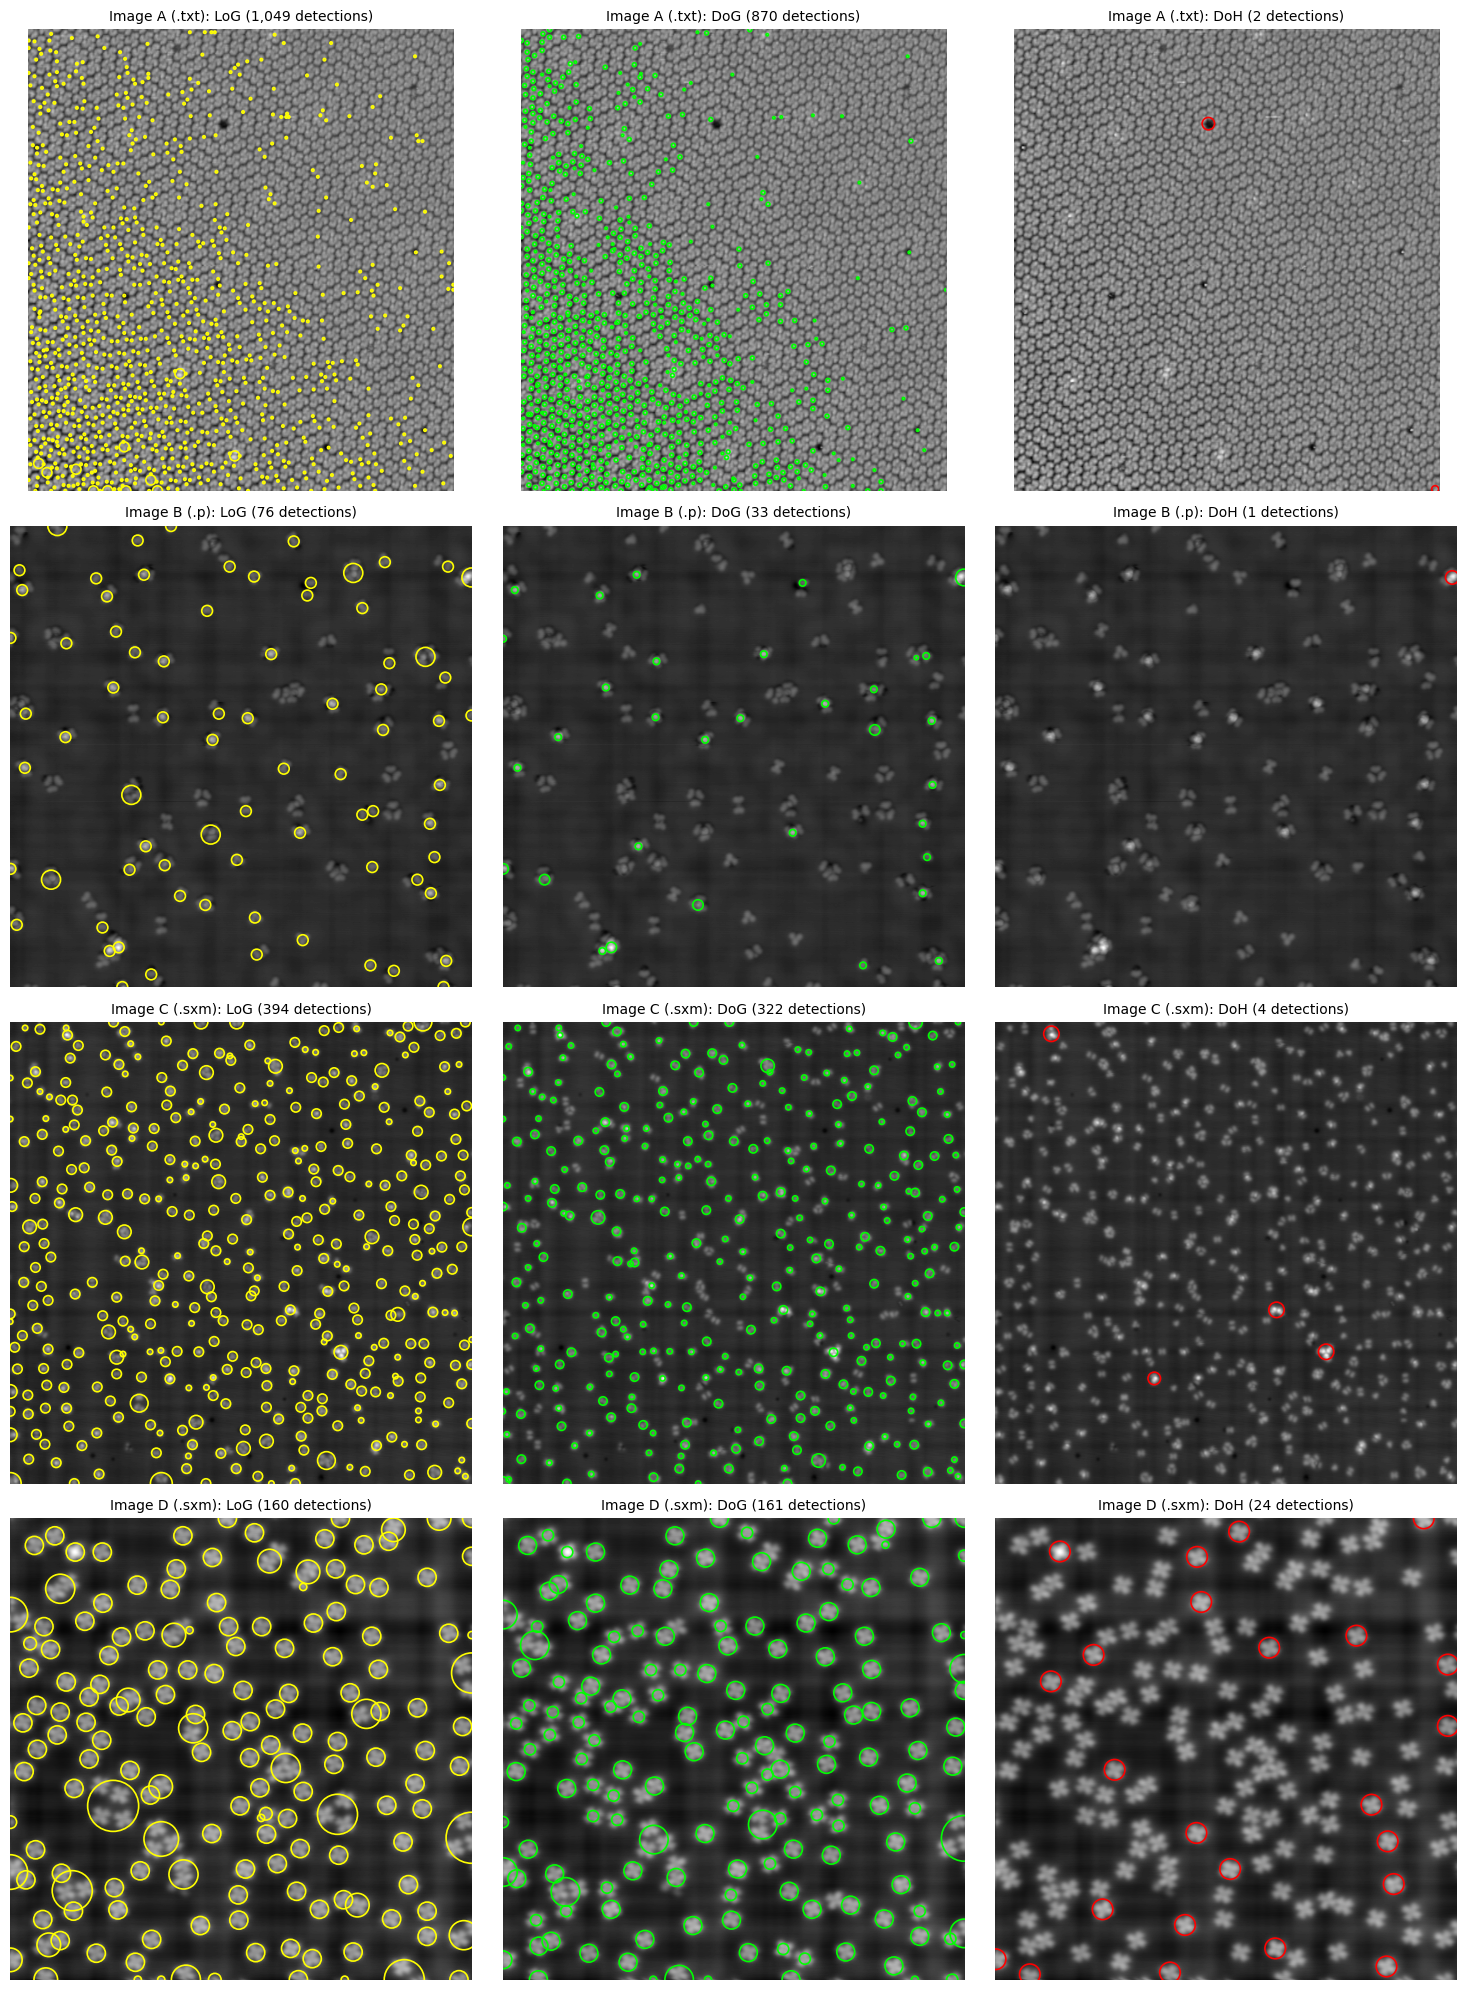

In [13]:
colors = {"LoG": "yellow", "DoG": "lime", "DoH": "red"}

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for row, (name, corrected) in enumerate(corrected_images.items()):
    blob_results = detect_blobs_three_ways(corrected)

    for col, (method, blobs) in enumerate(blob_results.items()):
        ax = axes[row, col]
        ax.imshow(corrected, cmap="gray")
        ax.set_title(f"{name}: {method} ({len(blobs):,} detections)", fontsize=10)

        for y, x, radius in blobs:
            circle = plt.Circle((x, y), radius, color=colors[method], linewidth=1.2, fill=False)
            ax.add_patch(circle)

        ax.set_axis_off()

plt.tight_layout()
plt.show()

## 9. Counts side by side: labelling vs blob detection

A summary table comparing the connected-component count to the three blob-detection counts for each image. Large discrepancies between methods are a signal that one of them is over- or under-detecting.

In [14]:
summary_rows = []

for name, corrected in corrected_images.items():
    blob_counts = detect_blobs_three_ways(corrected)
    summary_rows.append({
        "Image": name,
        "Connected-component": len(results[name]["regions"]),
        "LoG": len(blob_counts["LoG"]),
        "DoG": len(blob_counts["DoG"]),
        "DoH": len(blob_counts["DoH"]),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Image")
print("Molecule counts by detection method:")
print(summary_df)

Molecule counts by detection method:
                Connected-component   LoG  DoG  DoH
Image                                              
Image A (.txt)                    2  1049  870    2
Image B (.p)                     86    76   33    1
Image C (.sxm)                  331   394  322    4
Image D (.sxm)                   97   160  161   24


## Summary

The blob-detection stage delivers two complementary outputs:

1. **Connected-component labelling** with `min_area=50` gives a robust, fast count of molecules per image and a DataFrame of shape properties (area, perimeter, centroid, bounding box) for every detection. This is the workhorse output that downstream analysis (clustering, species classification) builds on.

2. **LoG / DoG / DoH blob detection** offers an independent cross-check. When the three methods agree with each other and with the connected-component count, we can trust the result. When they diverge, that's a flag for visual inspection.

The `results` dict, populated in section 4, holds the labelled region map, the filtered regions, and the property DataFrame for each of the four images. These structures feed directly into the final pipeline assembly in `pipeline_overview.ipynb`.


Websites:
* [Image manipulation with SciPy and Numpy](https://scipy-lectures.org/advanced/image_processing/#blurring-smoothing)
* [skimage](https://scikit-image.org/)
* [OpenCV](https://docs.opencv.org/4.5.5/)
* [nanonispyfit](https://github.com/jhellerstedt/spm-image-viewer)
* https://pyimagesearch.com/2015/03/23/sliding-windows-for-object-detection-with-python-and-opencv/
* https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_blob.html
* https://learnopencv.com/blob-detection-using-opencv-python-c/